# PRACTICAL 3 - Basic Statistics - Measures of Central Tendencies and Variance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv(r"C:\Users\Siddhi\Downloads\Iris.csv")

In [5]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
df.groupby(["Species"]).count()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,,
Iris-setosa,50,50,50,50,50
Iris-versicolor,50,50,50,50,50
Iris-virginica,50,50,50,50,50


In [10]:
df.groupby(["Species"]).SepalLengthCm.mean()

Species
Iris-setosa        5.006
Iris-versicolor    5.936
Iris-virginica     6.588
Name: SepalLengthCm, dtype: float64

In [11]:
df.groupby(["Species"]).PetalLengthCm.mean()

Species
Iris-setosa        1.464
Iris-versicolor    4.260
Iris-virginica     5.552
Name: PetalLengthCm, dtype: float64

In [12]:
df.groupby(["Species"]).SepalLengthCm.std()

Species
Iris-setosa        0.352490
Iris-versicolor    0.516171
Iris-virginica     0.635880
Name: SepalLengthCm, dtype: float64

In [13]:
df.groupby(["Species"]).PetalLengthCm.std()

Species
Iris-setosa        0.173511
Iris-versicolor    0.469911
Iris-virginica     0.551895
Name: PetalLengthCm, dtype: float64

In [15]:
print("Q1")
df.groupby(["Species"]).PetalLengthCm.quantile(0.25)

Q1


Species
Iris-setosa        1.4
Iris-versicolor    4.0
Iris-virginica     5.1
Name: PetalLengthCm, dtype: float64

In [16]:
print("Q2 or Mediean")
df.groupby(["Species"]).PetalLengthCm.quantile(0.50)

Q2 or Mediean


Species
Iris-setosa        1.50
Iris-versicolor    4.35
Iris-virginica     5.55
Name: PetalLengthCm, dtype: float64

In [17]:
print("Q3")
df.groupby(["Species"]).PetalLengthCm.quantile(0.75)

Q3


Species
Iris-setosa        1.575
Iris-versicolor    4.600
Iris-virginica     5.875
Name: PetalLengthCm, dtype: float64

In [18]:
print("IQR = Q3 - Q1")
IQR = (df.groupby(["Species"]).PetalLengthCm.quantile(0.75) - df.groupby(["Species"]).PetalLengthCm.quantile(0.25))
IQR

IQR = Q3 - Q1


Species
Iris-setosa        0.175
Iris-versicolor    0.600
Iris-virginica     0.775
Name: PetalLengthCm, dtype: float64

# # PRACTICAL 4 - Data Analytics I - Linear Regression

In [19]:
df1 = pd.read_csv(r"C:\Users\Siddhi\Downloads\HousingData.csv")

In [20]:
df1

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [34]:
df1.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [35]:
df1 = df1.dropna()

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [37]:
X = df1.drop("MEDV", axis=1)
y = df1["MEDV"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, random_state = 42)

In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
y_pred = model.predict(X_test)

In [43]:
X_test

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
93,0.02875,28.0,15.04,0.0,0.464,6.211,28.9,3.6659,4,270,18.2,396.33,6.21
352,0.07244,60.0,1.69,0.0,0.411,5.884,18.5,10.7103,4,411,18.3,392.33,7.79
319,0.47547,0.0,9.90,0.0,0.544,6.113,58.8,4.0019,4,304,18.4,396.23,12.73
65,0.03584,80.0,3.37,0.0,0.398,6.290,17.8,6.6115,4,337,16.1,396.90,4.67
499,0.17783,0.0,9.69,0.0,0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
470,4.34879,0.0,18.10,0.0,0.580,6.167,84.0,3.0334,24,666,20.2,396.90,16.29
97,0.12083,0.0,2.89,0.0,0.445,8.069,76.0,3.4952,2,276,18.0,396.90,4.21
137,0.35233,0.0,21.89,0.0,0.624,6.454,98.4,1.8498,4,437,21.2,394.08,14.59
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94


In [44]:
y_pred

array([29.22850199, 17.5037472 , 21.80803847, 30.4942528 , 18.50265527,
       34.7432311 , 22.07369779, 30.7541295 , 33.52029866, 14.82910783,
       22.14507214, 41.26427356, 22.51242483, 16.87300668, 19.0023074 ,
       20.77110711, 17.26921288, 15.48568273, 22.69482862, 14.12652975,
       18.19319969, 20.48292217, 17.04235173, 29.66737037, 26.09718411,
       16.06132841, 27.09746911, 31.45656662, 22.64238912, 27.06681913,
       41.10181897, 18.21320236, 23.062681  , 17.41202659, 17.39546606,
       21.076803  , 22.38598488, 21.66963934, 22.9118984 , 20.80249561,
       27.70046219, 34.60121409, 22.25931447, 30.83868791, 35.33229137,
       19.76393425, 24.99195034, 10.39133132, 19.75538217, 25.31114768,
       21.55934818, 25.89776968, 14.23212614, 18.66822307, 18.34126683,
       24.31756905, 43.40891373, 22.87668508, 15.3452895 , 23.17268086,
       21.11796307, 21.4821572 , 14.66508216, 28.92300146, -3.71655126,
       32.60224615, 16.81628299, 31.90077457, 24.78013157, 20.11

In [45]:
y_test

93     25.0
352    18.6
319    21.0
65     23.5
499    17.5
       ... 
470    19.9
97     38.7
137    17.1
3      33.4
22     15.2
Name: MEDV, Length: 79, dtype: float64

In [40]:
mse = mean_squared_error(y_test, y_pred)
print("mse", mse)

mse 31.454047664950917


In [41]:
r2 = r2_score(y_test, y_pred)
print("r2_score", r2)

r2_score 0.6270849941673186


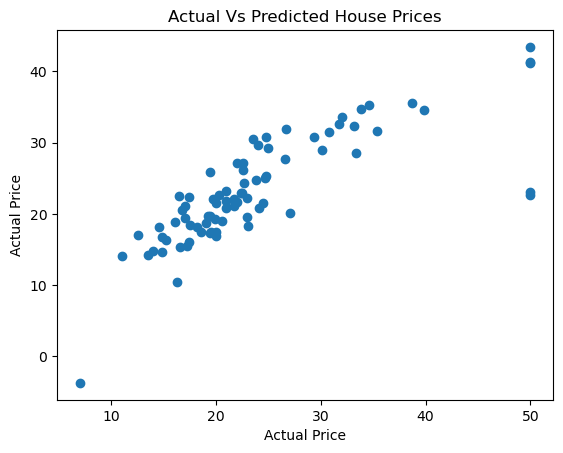

In [42]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Actual Price")
plt.title("Actual Vs Predicted House Prices")
plt.show()

# PRACTICAL 5 - Data Analytics II - Logistic Regression

In [46]:
df2 = pd.read_csv(r"C:\Users\Siddhi\Desktop\Data Science\Dataset\Social_Network_Ads.csv")
df2

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

In [49]:
X = df2[["Age","EstimatedSalary"]]
y = df2["Purchased"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)

In [90]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [91]:
X_test

array([[-0.11210953,  0.3100623 , -0.49582097,  0.48403749, -0.05143998],
       [-1.42536012, -0.17225683,  1.92563026, -1.26851205, -1.26670948],
       [ 0.96236822,  2.23933883, -0.98011121,  1.76924049,  1.43388941],
       [ 0.00727689,  0.18948252, -0.25367584,  0.36720086,  0.35364985],
       [-0.04047768,  1.15412078, -0.49582097,  0.54245581,  0.21861991],
       [-1.11495543, -0.53399618,  0.95704977, -1.38534869, -1.13167953],
       [-0.32700508, -0.29283662, -0.25367584, -0.15856401,  0.08358997],
       [ 1.51154574,  1.27470056,  0.2306144 ,  0.71771076,  1.43388941],
       [-0.23149595,  0.43064208, -1.9486917 ,  0.36720086,  0.35364985],
       [ 0.10278602, -0.05167705, -0.73796609,  0.01669095, -0.05143998],
       [ 0.77134995,  0.79238143,  0.47275953,  0.71771076,  1.02879957],
       [-1.56862382, -1.25747488, -0.01153072, -1.443767  , -1.53676936],
       [-0.99556902, -0.4134164 ,  1.19919489, -1.50218532, -1.40173942],
       [-1.64025567, -1.1368951 ,  0.2

In [53]:
model_1 = LogisticRegression()
model_1.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [55]:
y_pred = model_1.predict(X_test)

In [56]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[71  2]
 [16 31]]


In [57]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

TP: 31
FP: 2
TN: 71
FN: 16


In [58]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
accuracy

np.float64(0.85)

In [59]:
error_rate = (FP + FN) / (TP + TN + FP + FN)
error_rate

np.float64(0.15)

In [60]:
precision = (TP) / (TP + FP)
precision

np.float64(0.9393939393939394)

In [61]:
recall = (TP ) / (TP + FN)
recall

np.float64(0.6595744680851063)

In [65]:
ac = accuracy_score(y_pred, y_test)
ac

0.85

# PRACTICAL 6 - Data Analytics III - Naive Bayes

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

In [66]:
df = pd.read_csv(r"C:\Users\Siddhi\Downloads\Iris.csv")

In [67]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [74]:
X = df.drop("Species", axis = 1)
y = df["Species"]

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [77]:
model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [79]:
y_pred = model.predict(X_test)
y_pred

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-setosa', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-setosa'], dtype='<U15')

In [80]:
y_test

73     Iris-versicolor
18         Iris-setosa
118     Iris-virginica
78     Iris-versicolor
76     Iris-versicolor
31         Iris-setosa
64     Iris-versicolor
141     Iris-virginica
68     Iris-versicolor
82     Iris-versicolor
110     Iris-virginica
12         Iris-setosa
36         Iris-setosa
9          Iris-setosa
19         Iris-setosa
56     Iris-versicolor
104     Iris-virginica
69     Iris-versicolor
55     Iris-versicolor
132     Iris-virginica
29         Iris-setosa
127     Iris-virginica
26         Iris-setosa
128     Iris-virginica
131     Iris-virginica
145     Iris-virginica
108     Iris-virginica
143     Iris-virginica
45         Iris-setosa
30         Iris-setosa
22         Iris-setosa
15         Iris-setosa
65     Iris-versicolor
11         Iris-setosa
42         Iris-setosa
146     Iris-virginica
51     Iris-versicolor
27         Iris-setosa
4          Iris-setosa
32         Iris-setosa
142     Iris-virginica
85     Iris-versicolor
86     Iris-versicolor
16         

In [82]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [86]:
ac = accuracy_score(y_test, y_pred)
ac

1.0

In [88]:
pc = precision_score(y_test, y_pred, average="macro")
pc

1.0

# PRACTICAL 7 - Text Analytics

In [98]:
# PRACTICAL 7 - Text Analytics
# - Take a sample text document.
# - Apply preprocessing steps: Tokenization, POS Tagging, Stop word removal, Stemming, Lemmatization.
# - Represent the document using Term Frequency (TF) and Inverse Document Frequency (IDF).


| Import              | Purpose                                   |
| ------------------- | ----------------------------------------- |
| `nltk`              | Main NLP library                          |
| `word_tokenize`     | Splits text into words/tokens             |
| `stopwords`         | Common unnecessary words like "is", "the" |
| `PorterStemmer`     | Reduces words to root form                |
| `WordNetLemmatizer` | Converts words to meaningful base form    |
| `pos_tag`           | Assigns grammar tags (noun, verb, etc.)   |
| `TfidfVectorizer`   | Converts text into numerical vectors      |


| Dataset                      | Purpose                      |
| ---------------------------- | ---------------------------- |
| `punkt`                      | Tokenizer model              |
| `stopwords`                  | List of stopwords            |
| `wordnet`                    | Dictionary for lemmatization |
| `averaged_perceptron_tagger` | POS tagging model            |


In [99]:
text = """Text analytics is the process of analyzing text data to extract useful information.
It involves tokenization, tagging, and cleaning of text."""

In [100]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer

In [114]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Siddhi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Siddhi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Siddhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Siddhi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Siddhi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Siddhi\AppData\Roaming\nltk_data...
[nltk_data]   Package avera

True

In [115]:
tokens = word_tokenize(text)
print("Tokens:\n", tokens)

Tokens:
 ['Text', 'analytics', 'is', 'the', 'process', 'of', 'analyzing', 'text', 'data', 'to', 'extract', 'useful', 'information', '.', 'It', 'involves', 'tokenization', ',', 'tagging', ',', 'and', 'cleaning', 'of', 'text', '.']


In [116]:
pos_tags = pos_tag(tokens)
print("\nPOS Tags:\n", pos_tags)


POS Tags:
 [('Text', 'NN'), ('analytics', 'NNS'), ('is', 'VBZ'), ('the', 'DT'), ('process', 'NN'), ('of', 'IN'), ('analyzing', 'VBG'), ('text', 'NN'), ('data', 'NNS'), ('to', 'TO'), ('extract', 'VB'), ('useful', 'JJ'), ('information', 'NN'), ('.', '.'), ('It', 'PRP'), ('involves', 'VBZ'), ('tokenization', 'NN'), (',', ','), ('tagging', 'NN'), (',', ','), ('and', 'CC'), ('cleaning', 'NN'), ('of', 'IN'), ('text', 'NN'), ('.', '.')]


In [117]:
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w.lower() not in stop_words]
print("\nAfter Stopword Removal:\n", filtered_tokens)


After Stopword Removal:
 ['Text', 'analytics', 'process', 'analyzing', 'text', 'data', 'extract', 'useful', 'information', '.', 'involves', 'tokenization', ',', 'tagging', ',', 'cleaning', 'text', '.']


In [118]:
ps = PorterStemmer()
stemmed = [ps.stem(w) for w in filtered_tokens]
print("\nStemmed Words:\n", stemmed)


Stemmed Words:
 ['text', 'analyt', 'process', 'analyz', 'text', 'data', 'extract', 'use', 'inform', '.', 'involv', 'token', ',', 'tag', ',', 'clean', 'text', '.']


In [119]:
lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(w) for w in filtered_tokens]
print("\nLemmatized Words:\n", lemmatized)


Lemmatized Words:
 ['Text', 'analytics', 'process', 'analyzing', 'text', 'data', 'extract', 'useful', 'information', '.', 'involves', 'tokenization', ',', 'tagging', ',', 'cleaning', 'text', '.']


In [133]:
documents = [
    "Text analytics is useful",
    "Text data analysis is important",
    "Analytics involves text processing"
]

In [134]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13 stored elements and shape (3, 9)>

In [135]:
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names:\n", feature_names)


Feature Names:
 ['analysis' 'analytics' 'data' 'important' 'involves' 'is' 'processing'
 'text' 'useful']


In [139]:
print("\nTF-IDF Matrix:\n", tfidf_matrix.toarray())


TF-IDF Matrix:
 [[0.         0.4804584  0.         0.         0.         0.4804584
  0.         0.37311881 0.63174505]
 [0.50461134 0.         0.50461134 0.50461134 0.         0.38376993
  0.         0.29803159 0.        ]
 [0.         0.44451431 0.         0.         0.5844829  0.
  0.5844829  0.34520502 0.        ]]


What Do These Numbers Mean?

Higher value = word is more important in that document.

Example:

0.52

means the word strongly represents that document.

What is TF-IDF?

TF-IDF combines:

1. TF (Term Frequency)

How many times a word appears in a document.

2. IDF (Inverse Document Frequency)

Checks whether the word is rare across all documents.

Rare words get higher importance.

Common words get lower importance.
